Fit: E[K] ≈ -0.865 + 1.543 log(N)


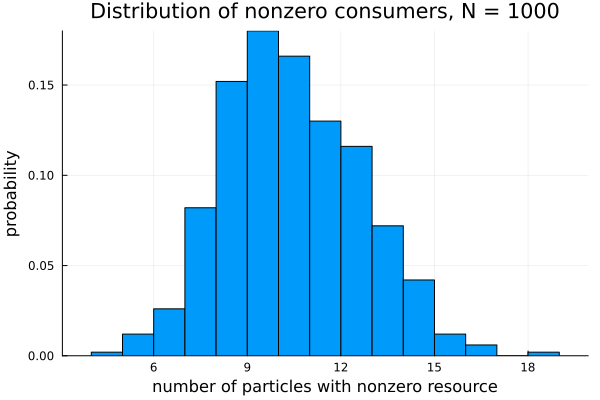

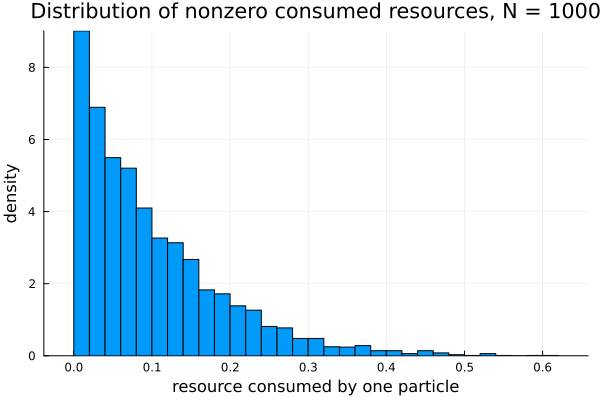

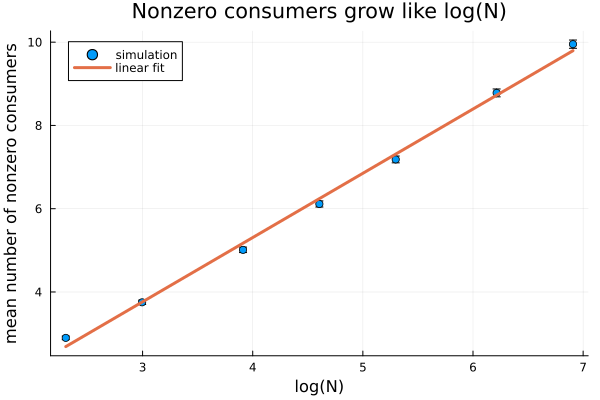

In [9]:
using Random
using Statistics
using StatsBase
using LinearAlgebra
using Plots


function one_simulation(;
    N::Int,
    D::Float64 = 1.0,
    dt::Float64 = 1e-4,
    a::Float64 = 0.02,
    x0::Float64 = 1.0,
    Lstock::Float64 = 1.0,
    Tfinal::Float64 = 10.0,
    rng = Random.default_rng())

    nsteps = Int(round(Tfinal / dt))
    x = fill(x0, N)
    resources = zeros(Float64, N)
    
    t = 0.0

    while t < Tfinal && sum(resources) < Lstock

        for i in 1:N
            x[i] = abs(x[i] + sqrt(2 * D * dt) * randn(rng))

            if x[i] <= a
                resources[i] += D / a * dt

            end
        end

        t += dt
    end

    total_resources = sum(resources)

    if total_resources > Lstock
        resources .*= Lstock / total_resources
        total_resources = Lstock
    end

    particle_nonzero = count(x -> x > 0.0, resources)

    depleted = total_resources >= Lstock

    return resources, total_resources, particle_nonzero, t, depleted

end

function run_simulations(;
    Ns = [10, 20, 50, 100, 200, 500, 1000],
    M::Int = 500,
    D::Float64 = 1.0,
    x0::Float64 = 1.0,
    a::Float64 = 0.02,
    dt::Float64 = 1e-4,
    Lstock::Float64 = 1.0,
    Tmax::Float64 = 10.0,
    seed::Int = 1234)

    rng = Xoshiro(seed)

    results = Dict{Int, Any}()

    for N in Ns

        K = zeros(Int, M)
        T = zeros(Float64, M)
        mean_resource_per_particle = zeros(Float64, M)
        all_resources = Vector{Vector{Float64}}(undef, M)

        for m in 1:M
            output = one_simulation(N=N, D=D, dt=dt, a=a, x0=x0, Lstock=Lstock, Tfinal=Tmax, rng=rng)

            K[m] = output[3]
            T[m] = output[4]
            mean_resource_per_particle[m] = mean(output[1])
            all_resources[m] = output[1]

        end
        mean_K = mean(K)
        std_K = std(K)
        mean_resource_per_particle = mean(mean_resource_per_particle)

        results[N] = (
            K = K,
            mean_K = mean_K,
            std_K = std_K,
            depletion_times = T,
            mean_resource_per_particle = mean_resource_per_particle,
            all_resources = all_resources
        )
    end

    return results

end

results = run_simulations()

Ns = sort(collect(keys(results)))
logN = log.(Ns)

mean_K = [results[N].mean_K for N in Ns]
std_K = [results[N].std_K for N in Ns]
M = length(results[Ns[1]].K)
se_K = std_K ./ sqrt(M)


Nplot = 1000
Kvals = results[Nplot].K

nonzero_his = histogram(
    Kvals;
    bins = minimum(Kvals):maximum(Kvals)+1,
    normalize = :probability,
    xlabel = "number of particles with nonzero resource",
    ylabel = "probability",
    label = "",
    title = "Distribution of nonzero consumers, N = $Nplot"
)

Nplot = 1000

all_resources = reduce(vcat, results[Nplot].all_resources)
nonzero_resources = all_resources[all_resources .> 0]

resource_his = histogram(
    nonzero_resources,
    bins = 40,
    normalize = :pdf,
    xlabel = "resource consumed by one particle",
    ylabel = "density",
    label = "",
    title = "Distribution of nonzero consumed resources, N = $Nplot"
)

X = hcat(ones(length(Ns)), logN)
β = X \ mean_K

intercept, slope = β
fit_K = X * β

println("Fit: E[K] ≈ $(round(intercept, digits=3)) + $(round(slope, digits=3)) log(N)")

fit = scatter(
    logN,
    mean_K;
    yerror = se_K,
    xlabel = "log(N)",
    ylabel = "mean number of nonzero consumers",
    label = "simulation",
    title = "Nonzero consumers grow like log(N)"
)

plot!(
    logN,
    fit_K;
    linewidth = 3,
    label = "linear fit"
)

display(nonzero_his)
display(resource_his)

display(fit)

        

